# 第3弾: アダプティブRSI（マルチタイムフレーム）戦略

## 戦略概要

- **アダプティブRSI戦略**: 5分足のRSI逆張りシグナルを、上位足（15分・30分・1時間）のトレンド方向でフィルタリングする手法
- 上位足RSIがトレンド方向を示しているときだけ、5分足のシグナルを通す
- 第1弾のミーンリバージョン（RSI+BB）との違いは「上位足フィルタの有無」のみ

| 項目 | 内容 |
|------|------|
| ロングエントリー | 5分足RSI < 30 かつ 上位足RSI > 50（上昇トレンド中） |
| ショートエントリー | 5分足RSI > 70 かつ 上位足RSI < 50（下降トレンド中） |
| エグジット | 5分足RSIが50に回帰（ロング: RSI > 50、ショート: RSI < 50） |
| 上位足タイムフレーム | 15分足・30分足・1時間足（感度分析で比較） |
| デフォルトパラメータ | 5分足RSI期間14、上位足RSI期間14、上位足=1時間足 |

## 検証対象

- USD/JPY（5分足、スプレッド片道0.002円）
- ETH/JPY（5分足、スプレッド片道=終値平均×0.00005）

## 1. セットアップ

In [1]:
!pip install japanize-matplotlib -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.1/4.1 MB 33.0 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done


In [2]:
import requests
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import time
from datetime import datetime, timedelta
import warnings
warnings.filterwarnings('ignore')

import japanize_matplotlib

print("ライブラリ読み込み完了")

ライブラリ読み込み完了


## 2. GMO Coin KLine API からデータ取得

- FX（USD_JPY）は `priceType=BID` が必要
- 暗号資産（ETH_JPY）は `priceType` 不要
- 上位足（15分・30分・1時間）は5分足データをリサンプリングして生成する

In [3]:
ENDPOINTS = {
    "fx":     "https://forex-api.coin.z.com/public/v1/klines",
    "crypto": "https://api.coin.z.com/public/v1/klines",
}

SYMBOL_CONFIG = {
    "USD_JPY": {"api": "fx",     "priceType": "BID"},
    "ETH_JPY": {"api": "crypto", "priceType": None},
}

def fetch_gmo_kline(symbol, interval="5min", days_back=365):
    config = SYMBOL_CONFIG.get(symbol)
    if config is None:
        print(f"未定義のシンボル: {symbol}")
        return pd.DataFrame()

    base_url = ENDPOINTS[config["api"]]
    all_data = []
    end_date = datetime.now()
    start_date = end_date - timedelta(days=days_back)
    current_date = start_date

    print(f"{symbol} の{interval}データを取得中...")
    print(f"  API: {config['api']} ({base_url})")
    print(f"  期間: {start_date.strftime('%Y-%m-%d')} -> {end_date.strftime('%Y-%m-%d')}")

    request_count = 0
    error_count = 0

    while current_date <= end_date:
        date_str = current_date.strftime("%Y%m%d")
        params = {"symbol": symbol, "interval": interval, "date": date_str}
        if config["priceType"]:
            params["priceType"] = config["priceType"]

        try:
            resp = requests.get(base_url, params=params, timeout=10)
            data = resp.json()
            if data.get("status") == 0 and data.get("data"):
                for c in data["data"]:
                    all_data.append({
                        "datetime": pd.to_datetime(
                            int(c["openTime"]), unit="ms", utc=True
                        ).tz_convert("Asia/Tokyo"),
                        "open":   float(c["open"]),
                        "high":   float(c["high"]),
                        "low":    float(c["low"]),
                        "close":  float(c["close"]),
                        "volume": float(c.get("volume", 0)),
                    })
                request_count += 1
        except Exception as e:
            error_count += 1
            if error_count <= 3:
                print(f"  {date_str}: {e}")

        current_date += timedelta(days=1)
        if request_count % 5 == 0 and request_count > 0:
            time.sleep(1)

    if not all_data:
        print(f"データ取得失敗: {symbol}")
        return pd.DataFrame()

    df = pd.DataFrame(all_data)
    df = df.sort_values("datetime").drop_duplicates(subset="datetime").reset_index(drop=True)

    print(f"{len(df):,}本取得 ({request_count}リクエスト)")
    print(f"  最初: {df['datetime'].iloc[0]}")
    print(f"  最後: {df['datetime'].iloc[-1]}")
    return df

print("データ取得関数を定義")

データ取得関数を定義


### USD/JPY データ取得

In [4]:
df_usdjpy = fetch_gmo_kline("USD_JPY", interval="5min", days_back=365)
df_usdjpy.head()

USD_JPY の5minデータを取得中...
  API: fx (https://forex-api.coin.z.com/public/v1/klines)
  期間: 2025-04-07 -> 2026-04-07
  20250713: ('Connection aborted.', ConnectionResetError(104, 'Connection reset by peer'))
  20250829: ('Connection aborted.', ConnectionResetError(104, 'Connection reset by peer'))
  20251023: ('Connection aborted.', RemoteDisconnected('Remote end closed connection without response'))
73,441本取得 (258リクエスト)
  最初: 2025-04-07 07:00:00+09:00
  最後: 2026-04-07 14:15:00+09:00


,datetime,open,high,low,close,volume
0,2025-04-07 07:00:00+09:00,145.494,145.638,144.949,145.132,0.0
1,2025-04-07 07:05:00+09:00,145.139,145.282,144.946,145.118,0.0
2,2025-04-07 07:10:00+09:00,145.118,145.447,145.113,145.346,0.0
3,2025-04-07 07:15:00+09:00,145.346,145.415,145.139,145.263,0.0
4,2025-04-07 07:20:00+09:00,145.261,145.270,145.067,145.239,0.0


### ETH/JPY データ取得

In [5]:
df_eth = fetch_gmo_kline("ETH_JPY", interval="5min", days_back=365)
df_eth.head()

ETH_JPY の5minデータを取得中...
  API: crypto (https://api.coin.z.com/public/v1/klines)
  期間: 2025-04-07 -> 2026-04-07
  20250410: ('Connection aborted.', RemoteDisconnected('Remote end closed connection without response'))
  20250711: ('Connection aborted.', ConnectionResetError(104, 'Connection reset by peer'))
  20250713: ('Connection aborted.', ConnectionResetError(104, 'Connection reset by peer'))
101,246本取得 (359リクエスト)
  最初: 2025-04-07 06:00:00+09:00
  最後: 2026-04-07 14:15:00+09:00


,datetime,open,high,low,close,volume
0,2025-04-07 06:00:00+09:00,231355.0,232705.0,230666.0,232120.0,350.36
1,2025-04-07 06:05:00+09:00,232159.0,232527.0,231045.0,231260.0,151.00
2,2025-04-07 06:10:00+09:00,231270.0,232666.0,231155.0,232121.0,75.68
3,2025-04-07 06:15:00+09:00,232175.0,233648.0,232172.0,233000.0,117.25
4,2025-04-07 06:20:00+09:00,232966.0,233537.0,232966.0,233270.0,70.28


## 3. テクニカル指標の計算

### RSI（Relative Strength Index）

RSIは直近N期間の値上がり幅と値下がり幅の比率から、相場の過熱・売られすぎを0〜100で表す指標。
一般に30以下で売られすぎ（逆張りロング候補）、70以上で買われすぎ（逆張りショート候補）とされる。

### 上位足RSIの生成方法

GMO Coin APIから直接上位足を取得する代わりに、5分足データをpandasでリサンプリングして上位足OHLCを生成し、そのcloseに対してRSIを計算する。
その後、5分足のインデックスに `merge_asof` でアラインすることで、5分足バーごとに「その時点での上位足RSI」を参照できるようにする。

In [6]:
def calc_rsi(series, period=14):
    """RSIを計算（Wilder's smoothing）"""
    delta = series.diff()
    gain = delta.clip(lower=0)
    loss = -delta.clip(upper=0)
    avg_gain = gain.ewm(alpha=1/period, min_periods=period).mean()
    avg_loss = loss.ewm(alpha=1/period, min_periods=period).mean()
    rs = avg_gain / avg_loss.replace(0, np.nan)
    rsi = 100 - (100 / (1 + rs))
    return rsi


def resample_ohlc(df, rule):
    """5分足DataFrameを指定ルール（15min/30min/1h）にリサンプリング"""
    df_indexed = df.set_index("datetime")
    resampled = df_indexed["close"].resample(rule).ohlc()
    resampled = resampled.dropna().reset_index()
    return resampled


def add_adaptive_rsi_indicators(df, rsi_period=14, htf_rsi_period=14, htf_rule="1h"):
    """
    アダプティブRSI戦略用の指標をDataFrameに追加。

    - rsi_5m: 5分足RSI（エントリーシグナル用）
    - htf_rsi: 上位足RSI（トレンドフィルタ用）
    """
    df = df.copy()

    # 5分足RSI
    df["rsi_5m"] = calc_rsi(df["close"], period=rsi_period)

    # 上位足リサンプリング + RSI計算
    htf = resample_ohlc(df, htf_rule)
    htf["htf_rsi"] = calc_rsi(htf["close"], period=htf_rsi_period)
    htf = htf[["datetime", "htf_rsi"]].dropna()

    # 5分足インデックスにアライン（上位足バーが確定したタイミングで参照）
    df = pd.merge_asof(
        df.sort_values("datetime"),
        htf.sort_values("datetime"),
        on="datetime",
        direction="backward"
    )

    return df.dropna(subset=["rsi_5m", "htf_rsi"]).reset_index(drop=True)


df_usdjpy = add_adaptive_rsi_indicators(df_usdjpy)
df_eth    = add_adaptive_rsi_indicators(df_eth)

print(f"USD/JPY: {len(df_usdjpy):,}本（指標計算後）")
print(f"ETH/JPY: {len(df_eth):,}本（指標計算後）")

USD/JPY: 73,273本（指標計算後）
ETH/JPY: 101,078本（指標計算後）


## 4. バックテスト

In [10]:
def backtest_adaptive_rsi(
    df,
    rsi_oversold=30,
    rsi_overbought=70,
    rsi_exit=50,
    use_htf_filter=True,
    spread=0.0,
    symbol_name=""
):
    """
    アダプティブRSI戦略のバックテスト（numpy配列化で高速化）。

    エントリー:
      - ロング: 5分足RSI < rsi_oversold かつ 上位足RSI > 50（上昇トレンド）
      - ショート: 5分足RSI > rsi_overbought かつ 上位足RSI < 50（下降トレンド）
    エグジット:
      - ロング: 5分足RSI > rsi_exit
      - ショート: 5分足RSI < rsi_exit
    """
    close     = df["close"].to_numpy()
    rsi_5m    = df["rsi_5m"].to_numpy()
    htf_rsi   = df["htf_rsi"].to_numpy()
    datetimes = df["datetime"].to_numpy()

    position    = 0
    entry_price = 0.0
    entry_time  = None
    trades      = []
    equity      = 0.0
    equity_curve = [0.0]

    for i in range(1, len(close)):
        c   = close[i]
        rsi = rsi_5m[i]
        htf = htf_rsi[i]

        htf_up   = (htf > 50) if use_htf_filter else True
        htf_down = (htf < 50) if use_htf_filter else True

        # --- エントリー ---
        if position == 0:
            if rsi < rsi_oversold and htf_up:
                position    = 1
                entry_price = c + spread
                entry_time  = datetimes[i]
            elif rsi > rsi_overbought and htf_down:
                position    = -1
                entry_price = c - spread
                entry_time  = datetimes[i]

        # --- エグジット ---
        elif position == 1 and rsi > rsi_exit:
            exit_price = c - spread
            pnl = exit_price - entry_price
            trades.append({
                "entry_time": entry_time, "exit_time": datetimes[i],
                "direction": "LONG",
                "entry_price": entry_price, "exit_price": exit_price,
                "pnl": pnl,
                "pnl_pct": pnl / entry_price * 100,
            })
            equity  += pnl
            position = 0

        elif position == -1 and rsi < rsi_exit:
            exit_price = c + spread
            pnl = entry_price - exit_price
            trades.append({
                "entry_time": entry_time, "exit_time": datetimes[i],
                "direction": "SHORT",
                "entry_price": entry_price, "exit_price": exit_price,
                "pnl": pnl,
                "pnl_pct": pnl / entry_price * 100,
            })
            equity  += pnl
            position = 0

        equity_curve.append(equity)

    # --- 集計 ---
    if not trades:
        print(f"{symbol_name}: トレード0件")
        return {"trades_df": pd.DataFrame(), "equity_curve": equity_curve, "total_trades": 0, "symbol": symbol_name}

    tdf = pd.DataFrame(trades)
    wins   = tdf[tdf["pnl"] > 0]
    losses = tdf[tdf["pnl"] <= 0]
    gp = wins["pnl"].sum()        if len(wins)   else 0
    gl = abs(losses["pnl"].sum()) if len(losses) else 0
    pf = gp / gl if gl > 0 else float("inf")
    eq = pd.Series(equity_curve)
    max_dd = (eq - eq.cummax()).min()
    sharpe = (
        tdf["pnl_pct"].mean() / tdf["pnl_pct"].std() * np.sqrt(len(tdf))
        if len(tdf) > 1 and tdf["pnl_pct"].std() > 0 else 0.0
    )
    hold_bars = (
        pd.to_datetime(tdf["exit_time"]) - pd.to_datetime(tdf["entry_time"])
    ).dt.total_seconds() / 300

    res = {
        "symbol": symbol_name, "total_trades": len(tdf),
        "wins": len(wins), "losses": len(losses),
        "win_rate": len(wins) / len(tdf) * 100,
        "total_pnl": tdf["pnl"].sum(), "avg_pnl": tdf["pnl"].mean(),
        "profit_factor": pf, "max_drawdown": max_dd,
        "sharpe_ratio": sharpe, "avg_hold_bars": hold_bars.mean(),
        "trades_df": tdf, "equity_curve": equity_curve,
    }

    label = "HTFフィルタあり" if use_htf_filter else "HTFフィルタなし"
    print(f"\n{'='*55}")
    print(f"{symbol_name} アダプティブRSI戦略 ({label})")
    print(f"{'='*55}")
    print(f"  トレード数      : {res['total_trades']}")
    print(f"  勝ち / 負け     : {res['wins']} / {res['losses']}")
    print(f"  勝率            : {res['win_rate']:.1f}%")
    print(f"  総損益          : {res['total_pnl']:.4f}")
    print(f"  平均損益        : {res['avg_pnl']:.4f}")
    print(f"  PF              : {res['profit_factor']:.3f}")
    print(f"  最大DD          : {res['max_drawdown']:.4f}")
    print(f"  シャープレシオ  : {res['sharpe_ratio']:.3f}")
    print(f"  平均保有        : {res['avg_hold_bars']:.0f}本（={res['avg_hold_bars']*5:.0f}分）")
    print(f"{'='*55}")
    return res

print("バックテスト関数を定義")

バックテスト関数を定義


### USD/JPY バックテスト（HTFフィルタあり / なし比較）

In [11]:
# HTFフィルタあり（デフォルト: 1時間足RSI）
results_usdjpy_htf = backtest_adaptive_rsi(
    df_usdjpy, use_htf_filter=True, spread=0.002, symbol_name="USD/JPY"
)

# HTFフィルタなし（第1弾のミーンリバージョンに近い条件）
results_usdjpy_no_htf = backtest_adaptive_rsi(
    df_usdjpy, use_htf_filter=False, spread=0.002, symbol_name="USD/JPY"
)


USD/JPY アダプティブRSI戦略 (HTFフィルタあり)
  トレード数      : 232
  勝ち / 負け     : 191 / 41
  勝率            : 82.3%
  総損益          : 22.5470
  平均損益        : 0.0972
  PF              : 4.496
  最大DD          : -2.1470
  シャープレシオ  : 6.539
  平均保有        : 22本（=110分）

USD/JPY アダプティブRSI戦略 (HTFフィルタなし)
  トレード数      : 986
  勝ち / 負け     : 619 / 367
  勝率            : 62.8%
  総損益          : -7.7850
  平均損益        : -0.0079
  PF              : 0.910
  最大DD          : -19.0410
  シャープレシオ  : -0.993
  平均保有        : 32本（=161分）


### ETH/JPY バックテスト（HTFフィルタあり / なし比較）

In [12]:
eth_spread = df_eth["close"].mean() * 0.00005
print(f"ETH/JPY 推定スプレッド: {eth_spread:.0f}円")

results_eth_htf = backtest_adaptive_rsi(
    df_eth, use_htf_filter=True, spread=eth_spread, symbol_name="ETH/JPY"
)

results_eth_no_htf = backtest_adaptive_rsi(
    df_eth, use_htf_filter=False, spread=eth_spread, symbol_name="ETH/JPY"
)

ETH/JPY 推定スプレッド: 23円

ETH/JPY アダプティブRSI戦略 (HTFフィルタあり)
  トレード数      : 285
  勝ち / 負け     : 225 / 60
  勝率            : 78.9%
  総損益          : 452140.0453
  平均損益        : 1586.4563
  PF              : 3.257
  最大DD          : -34326.8380
  シャープレシオ  : 7.843
  平均保有        : 19本（=94分）

ETH/JPY アダプティブRSI戦略 (HTFフィルタなし)
  トレード数      : 1312
  勝ち / 負け     : 869 / 443
  勝率            : 66.2%
  総損益          : -126440.8513
  平均損益        : -96.3726
  PF              : 0.946
  最大DD          : -281817.4755
  シャープレシオ  : -0.269
  平均保有        : 23本（=116分）


## 5. 結果の可視化

In [13]:
def plot_adaptive_rsi_results(results, df, label=""):
    """アダプティブRSI戦略の結果を4分割チャート + 月別損益で可視化"""
    tdf = results["trades_df"]
    if tdf.empty:
        print("トレード0件のためスキップ")
        return
    symbol = results["symbol"]

    fig, axes = plt.subplots(4, 1, figsize=(16, 16),
                             gridspec_kw={"height_ratios": [3, 1, 1, 2]})
    fig.suptitle(f"{symbol} アダプティブRSI戦略 {label}", fontsize=16, fontweight="bold")

    # 価格 + エントリーポイント
    ax = axes[0]
    ax.plot(df["datetime"], df["close"], color="black", lw=0.5, alpha=0.8, label="Close")
    longs  = tdf[tdf["direction"] == "LONG"]
    shorts = tdf[tdf["direction"] == "SHORT"]
    if len(longs):
        ax.scatter(longs["entry_time"], longs["entry_price"],
                   marker="^", color="green", s=30, alpha=0.7, label="Long", zorder=5)
    if len(shorts):
        ax.scatter(shorts["entry_time"], shorts["entry_price"],
                   marker="v", color="red", s=30, alpha=0.7, label="Short", zorder=5)
    ax.legend(loc="upper left", fontsize=8)
    ax.set_ylabel("Price")
    ax.set_title("価格 + エントリーポイント")

    # 5分足RSI + 上位足RSI
    ax = axes[1]
    ax.plot(df["datetime"], df["rsi_5m"],  color="orange", lw=0.5, label="RSI 5m")
    ax.plot(df["datetime"], df["htf_rsi"], color="blue",   lw=0.8, alpha=0.6, label="RSI HTF")
    ax.axhline(70, color="red",   lw=0.5, ls="--", alpha=0.5)
    ax.axhline(50, color="gray",  lw=0.5, ls="--", alpha=0.5)
    ax.axhline(30, color="green", lw=0.5, ls="--", alpha=0.5)
    ax.set_ylim(0, 100)
    ax.legend(loc="upper left", fontsize=8)
    ax.set_ylabel("RSI")
    ax.set_title("5分足RSI vs 上位足RSI")

    # 各トレードPnL
    ax = axes[2]
    colors = ["green" if p > 0 else "red" for p in tdf["pnl"]]
    ax.bar(range(len(tdf)), tdf["pnl"], color=colors, alpha=0.7)
    ax.axhline(0, color="black", lw=0.5)
    ax.set_ylabel("PnL")
    ax.set_xlabel("Trade #")
    ax.set_title("各トレード損益")

    # エクイティカーブ
    ax = axes[3]
    eq = results["equity_curve"]
    ax.plot(eq, color="navy", lw=1)
    ax.fill_between(range(len(eq)), eq, alpha=0.1, color="navy")
    ax.axhline(0, color="black", lw=0.5, ls="--")
    ax.set_ylabel("累積損益")
    ax.set_xlabel("Bar")
    ax.set_title("エクイティカーブ")

    plt.tight_layout()
    plt.show()

    # 月別損益
    tdf2 = tdf.copy()
    tdf2["month"] = tdf2["entry_time"].dt.to_period("M")
    monthly = tdf2.groupby("month")["pnl"].sum()
    if len(monthly) > 1:
        fig2, ax2 = plt.subplots(figsize=(14, 3))
        mc = ["green" if v > 0 else "red" for v in monthly.values]
        ax2.bar(range(len(monthly)), monthly.values, color=mc, alpha=0.7)
        ax2.set_xticks(range(len(monthly)))
        ax2.set_xticklabels([str(m) for m in monthly.index], rotation=45, fontsize=8)
        ax2.axhline(0, color="black", lw=0.5)
        ax2.set_title(f"{symbol} 月別損益 {label}")
        ax2.set_ylabel("PnL")
        plt.tight_layout()
        plt.show()

print("可視化関数を定義")

可視化関数を定義


### USD/JPY 結果（HTFフィルタあり）

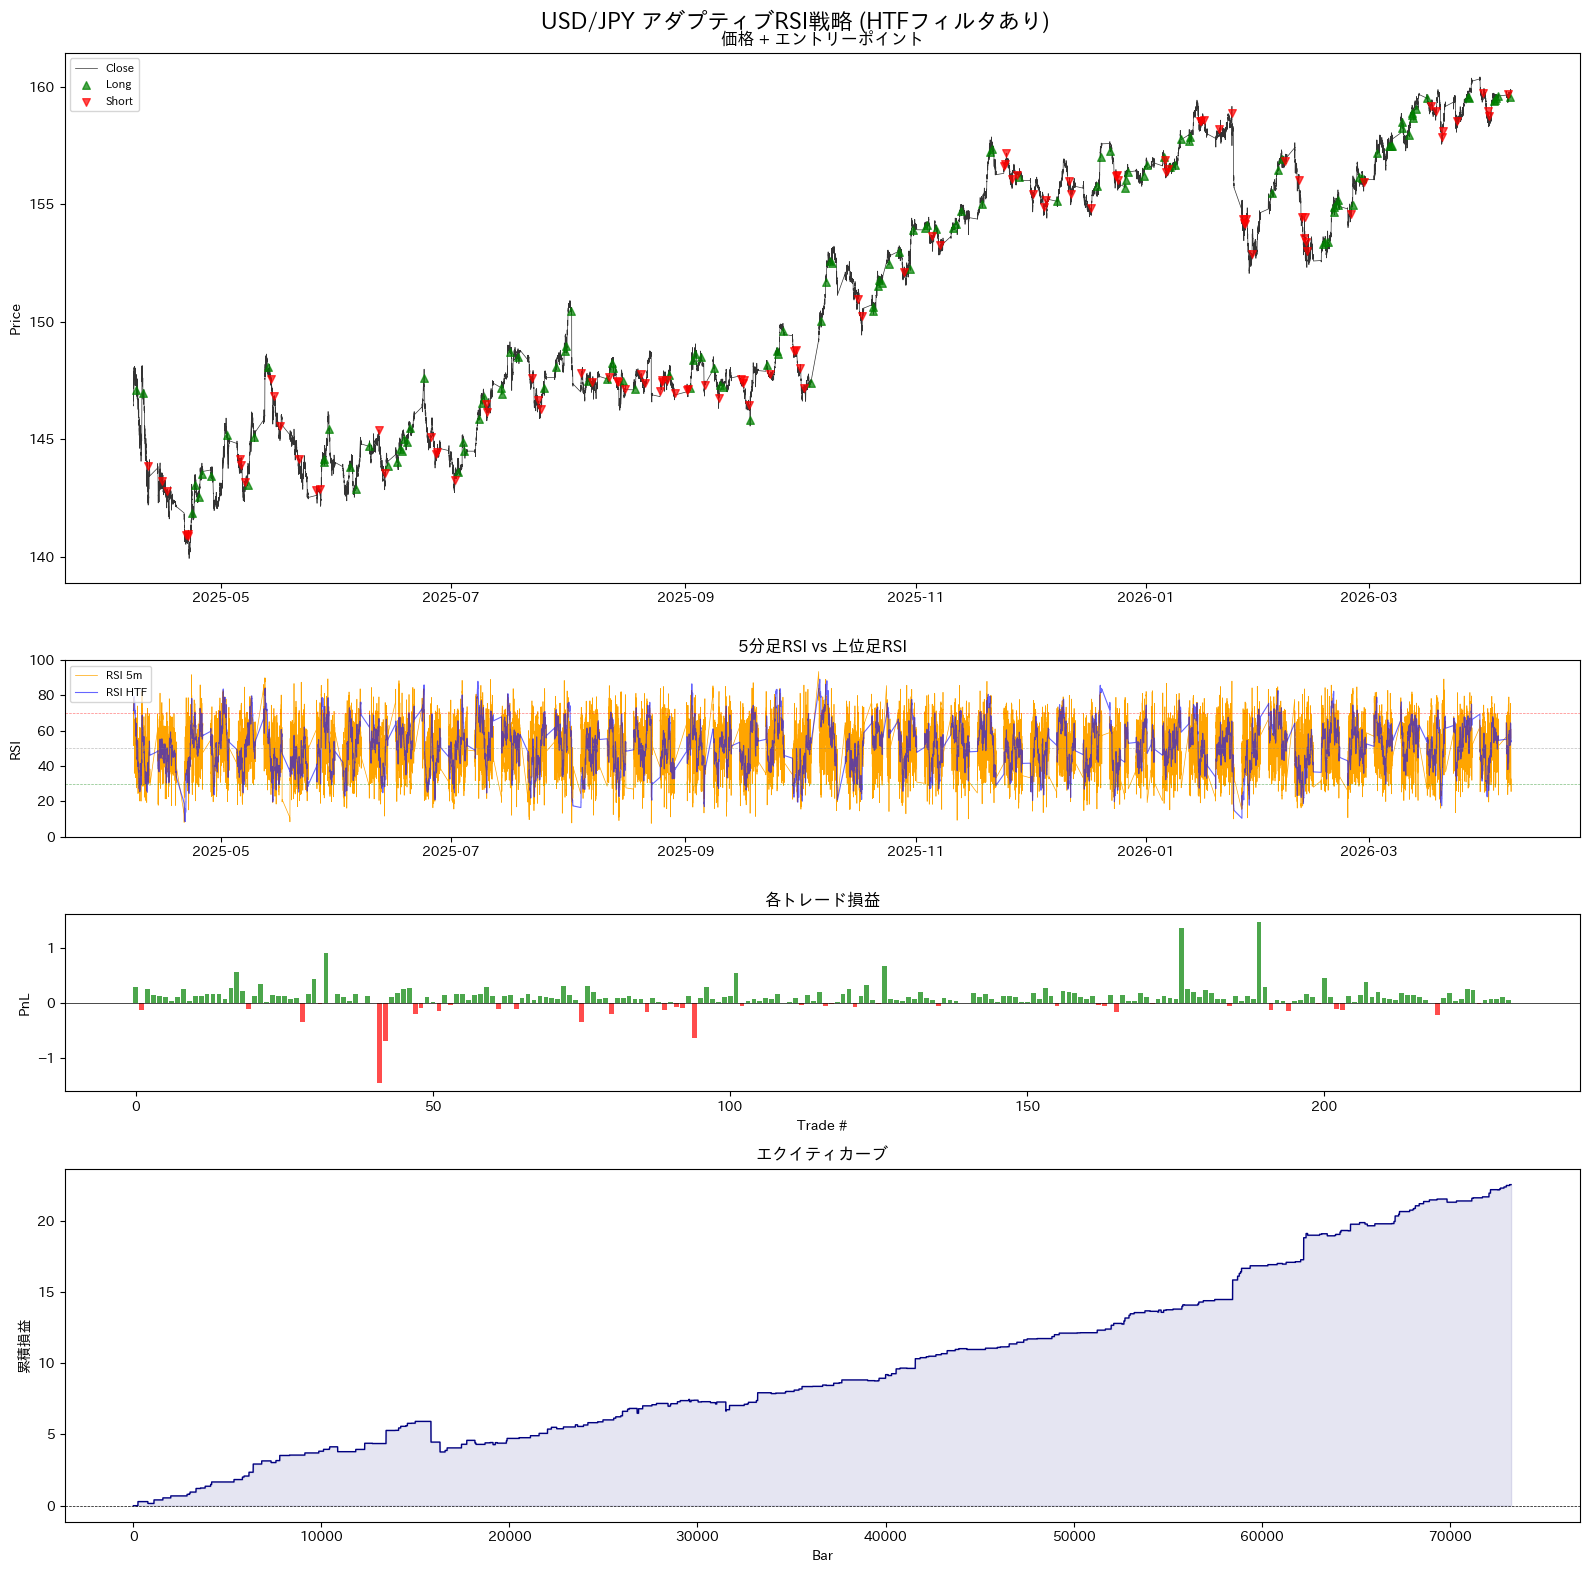

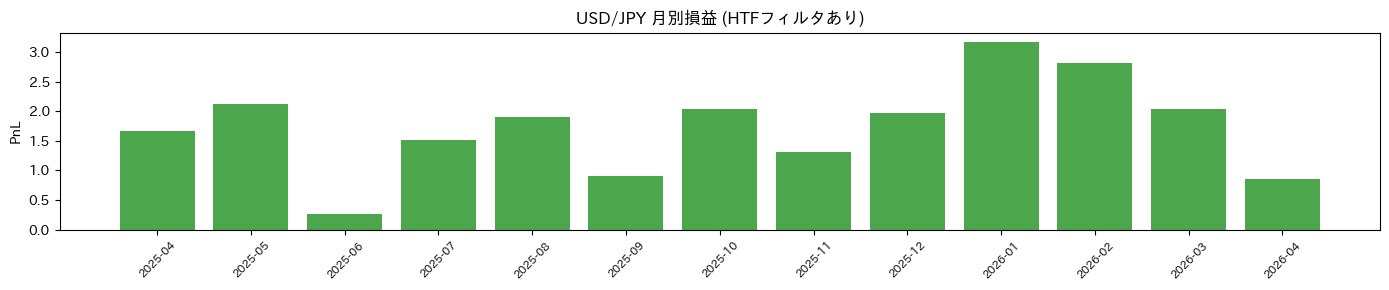

In [14]:
plot_adaptive_rsi_results(results_usdjpy_htf, df_usdjpy, label="(HTFフィルタあり)")

### ETH/JPY 結果（HTFフィルタあり）

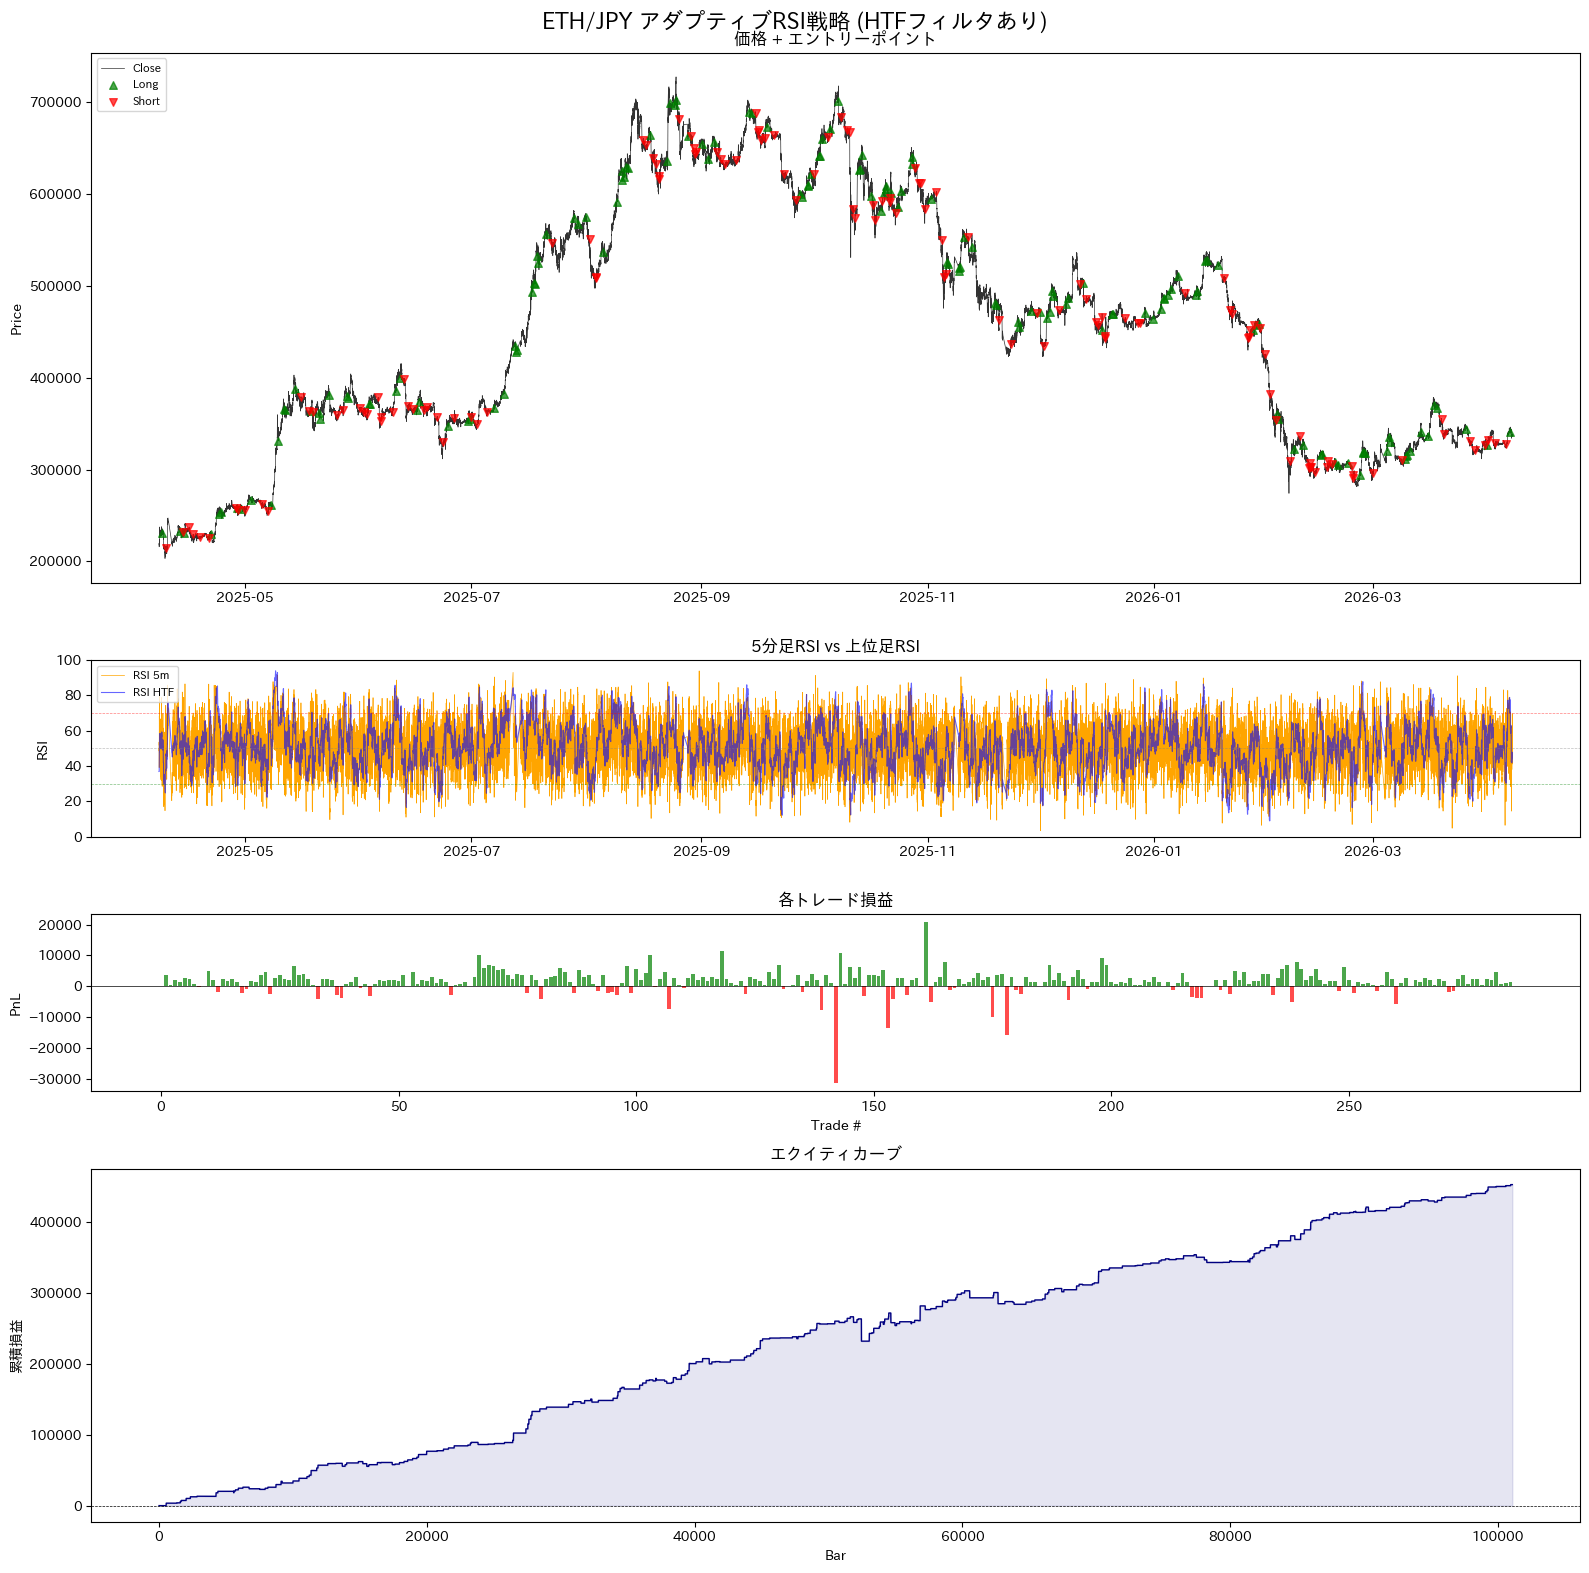

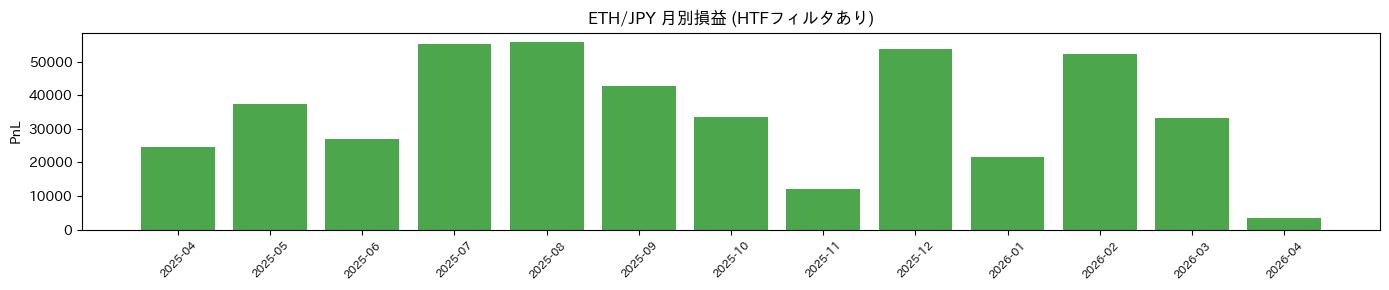

In [15]:
plot_adaptive_rsi_results(results_eth_htf, df_eth, label="(HTFフィルタあり)")

## 6. パラメータ感度分析

In [16]:
def adaptive_rsi_sensitivity(df_5m, symbol_name, spread):
    """
    上位足タイムフレーム x RSI閾値 のグリッドサーチ。
    各パターンで指標を再計算してバックテストを実行する。
    """
    htf_rules      = ["15min", "30min", "1h"]
    oversold_list  = [25, 30, 35]
    overbought_list= [65, 70, 75]

    total = len(htf_rules) * len(oversold_list)
    print(f"{symbol_name} 感度分析中... ({total}パターン)")

    records = []
    for rule in htf_rules:
        df_ind = add_adaptive_rsi_indicators(df_5m, htf_rule=rule)
        for os_val, ob_val in zip(oversold_list, overbought_list):
            res = backtest_adaptive_rsi(
                df_ind,
                rsi_oversold=os_val,
                rsi_overbought=ob_val,
                use_htf_filter=True,
                spread=spread,
                symbol_name=""
            )
            if res["total_trades"] == 0:
                continue
            records.append({
                "上位足": rule,
                "RSI閾値": f"{os_val}/{ob_val}",
                "トレード数": res["total_trades"],
                "勝率%": round(res["win_rate"], 1),
                "総損益": round(res["total_pnl"], 4),
                "PF": round(res["profit_factor"], 3),
                "最大DD": round(res["max_drawdown"], 4),
            })

    grid = pd.DataFrame(records).sort_values("PF", ascending=False).reset_index(drop=True)
    print(f"\n{symbol_name} TOP10 (PF順):")
    print(grid.head(10).to_string())
    return grid

print("感度分析関数を定義")

感度分析関数を定義


### USD/JPY 感度分析

In [18]:
base_cols = ["datetime", "open", "high", "low", "close", "volume"]
df_usdjpy_raw = df_usdjpy[base_cols].copy()

grid_usdjpy = adaptive_rsi_sensitivity(df_usdjpy_raw, "USD/JPY", spread=0.002)

USD/JPY 感度分析中... (9パターン)

 アダプティブRSI戦略 (HTFフィルタあり)
  トレード数      : 54
  勝ち / 負け     : 45 / 9
  勝率            : 83.3%
  総損益          : 5.9730
  平均損益        : 0.1106
  PF              : 4.505
  最大DD          : -0.9410
  シャープレシオ  : 3.051
  平均保有        : 12本（=60分）

 アダプティブRSI戦略 (HTFフィルタあり)
  トレード数      : 23
  勝ち / 負け     : 21 / 2
  勝率            : 91.3%
  総損益          : 2.9900
  平均損益        : 0.1300
  PF              : 2.843
  最大DD          : -1.6220
  シャープレシオ  : 1.238
  平均保有        : 15本（=73分）

 アダプティブRSI戦略 (HTFフィルタあり)
  トレード数      : 90
  勝ち / 負け     : 81 / 9
  勝率            : 90.0%
  総損益          : 6.8050
  平均損益        : 0.0756
  PF              : 3.060
  最大DD          : -1.4920
  シャープレシオ  : 2.617
  平均保有        : 19本（=96分）

 アダプティブRSI戦略 (HTFフィルタあり)
  トレード数      : 203
  勝ち / 負け     : 164 / 39
  勝率            : 80.8%
  総損益          : 13.1120
  平均損益        : 0.0646
  PF              : 2.614
  最大DD          : -1.3590
  シャープレシオ  : 4.249
  平均保有        : 15本（=75分）

 アダプティブRSI戦略 (HTFフィルタあり)
  トレー

### ETH/JPY 感度分析

In [19]:
base_cols = ["datetime", "open", "high", "low", "close", "volume"]
df_eth_raw = df_eth[base_cols].copy()

eth_spread = df_eth["close"].mean() * 0.00005
grid_eth = adaptive_rsi_sensitivity(df_eth_raw, "ETH/JPY", spread=eth_spread)

ETH/JPY 感度分析中... (9パターン)

 アダプティブRSI戦略 (HTFフィルタあり)
  トレード数      : 51
  勝ち / 負け     : 42 / 9
  勝率            : 82.4%
  総損益          : 100676.5660
  平均損益        : 1974.0503
  PF              : 7.713
  最大DD          : -7104.3785
  シャープレシオ  : 6.200
  平均保有        : 11本（=55分）

 アダプティブRSI戦略 (HTFフィルタあり)
  トレード数      : 17
  勝ち / 負け     : 16 / 1
  勝率            : 94.1%
  総損益          : 75094.1887
  平均損益        : 4417.3052
  PF              : 37.234
  最大DD          : -2072.4595
  シャープレシオ  : 5.978
  平均保有        : 7本（=34分）

 アダプティブRSI戦略 (HTFフィルタあり)
  トレード数      : 65
  勝ち / 負け     : 62 / 3
  勝率            : 95.4%
  総損益          : 175689.1331
  平均損益        : 2702.9097
  PF              : 18.375
  最大DD          : -7397.4595
  シャープレシオ  : 8.447
  平均保有        : 10本（=48分）

 アダプティブRSI戦略 (HTFフィルタあり)
  トレード数      : 227
  勝ち / 負け     : 186 / 41
  勝率            : 81.9%
  総損益          : 368011.6957
  平均損益        : 1621.1969
  PF              : 4.812
  最大DD          : -16727.4595
  シャープレシオ  : 8.962
  平均保有       

## 7. 比較サマリー

In [20]:
def get_best_params(grid, min_trades=10):
    filtered = grid[grid["トレード数"] >= min_trades]
    if filtered.empty:
        return None
    return filtered.iloc[0]


def print_summary(results_no_htf, results_htf, best, symbol, unit=""):
    print(f"\n{'='*70}")
    print(f"{symbol} アダプティブRSI戦略 最終比較（5分足）")
    print(f"  HTFフィルタなし vs あり vs 感度分析ベスト")
    print(f"{'='*70}")

    rows = [
        ("HTFフィルタなし",  results_no_htf),
        ("HTFフィルタあり (1h, RSI30/70)", results_htf),
    ]
    for label, r in rows:
        if r["total_trades"] == 0:
            continue
        print(f"  [{label}]")
        print(f"    トレード数: {r['total_trades']}  勝率: {r['win_rate']:.1f}%  "
              f"総損益: {r['total_pnl']:.4f}{unit}  PF: {r['profit_factor']:.3f}  "
              f"最大DD: {r['max_drawdown']:.4f}{unit}")

    if best is not None:
        print(f"  [感度分析TOP ({best['上位足']}, RSI{best['RSI閾値']})]")
        print(f"    トレード数: {best['トレード数']}  勝率: {best['勝率%']}%  "
              f"総損益: {best['総損益']}{unit}  PF: {best['PF']}  "
              f"最大DD: {best['最大DD']}{unit}")

    print(f"{'='*70}")
    print("* 感度分析の最適化パラメータはin-sampleの結果。")


best_usdjpy = get_best_params(grid_usdjpy)
best_eth    = get_best_params(grid_eth)

print_summary(results_usdjpy_no_htf, results_usdjpy_htf, best_usdjpy, "USD/JPY", unit="円")
print_summary(results_eth_no_htf,    results_eth_htf,    best_eth,    "ETH/JPY", unit="円")


USD/JPY アダプティブRSI戦略 最終比較（5分足）
  HTFフィルタなし vs あり vs 感度分析ベスト
  [HTFフィルタなし]
    トレード数: 986  勝率: 62.8%  総損益: -7.7850円  PF: 0.910  最大DD: -19.0410円
  [HTFフィルタあり (1h, RSI30/70)]
    トレード数: 232  勝率: 82.3%  総損益: 22.5470円  PF: 4.496  最大DD: -2.1470円
  [感度分析TOP (15min, RSI25/65)]
    トレード数: 54  勝率: 83.3%  総損益: 5.973円  PF: 4.505  最大DD: -0.941円
* 感度分析の最適化パラメータはin-sampleの結果。

ETH/JPY アダプティブRSI戦略 最終比較（5分足）
  HTFフィルタなし vs あり vs 感度分析ベスト
  [HTFフィルタなし]
    トレード数: 1312  勝率: 66.2%  総損益: -126440.8513円  PF: 0.946  最大DD: -281817.4755円
  [HTFフィルタあり (1h, RSI30/70)]
    トレード数: 285  勝率: 78.9%  総損益: 452140.0453円  PF: 3.257  最大DD: -34326.8380円
  [感度分析TOP (15min, RSI30/70)]
    トレード数: 17  勝率: 94.1%  総損益: 75094.1887円  PF: 37.234  最大DD: -2072.4595円
* 感度分析の最適化パラメータはin-sampleの結果。
